# Delivery-Time Regression: Tuned Ridge, Random Forest, and Stacking

This bounded experiment asks whether tuning Ridge and random forest improves their combination, and whether a combination can improve on the published HGB reference. It compares the previous fixed configurations with a predeclared grid of **12 Ridge and 6 random-forest candidates**.

**Model decision:** HGB remains the final regression model. The tuned three-model stack achieves a mean outer-validation MAE of **4.2374 days**, compared with **4.2378 days** for HGB. Its improvement of approximately **36 seconds** is too small to justify the added fitting complexity. Stacking is retained here as an exploratory comparison for discussion.

All new fitting and evaluation use the existing **64,634 training orders**. The **31,836-order random test set is not loaded or scored by this experiment**. Results below are outer-fold validation results, not test results. Each outer fold is excluded from this run's candidate selection, preprocessing fits, and meta-weight fitting.

The HGB reference was previously selected using these same five folds. Its configuration is frozen here; only the new Ridge/RF selection and stacking procedure are nested. These scores do not independently validate the entire historical model-selection process. They remain retrospective development evidence: nesting prevents new fold contamination but does not create an untouched confirmation dataset. Random validation describes the historical order mixture rather than future-month forecasting.

Running this notebook displays saved aggregates. It does not retrain models.


In [1]:
from pathlib import Path
import hashlib
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

def locate_root():
    for parent in [Path.cwd(), *Path.cwd().parents]:
        for candidate in [parent, parent / "nested_tuning", parent / "random_stacking/nested_tuning",
                          parent / "Regression/random_stacking/nested_tuning",
                          parent / "Phase 2/Regression/random_stacking/nested_tuning"]:
            if (candidate / "config/protocol.json").is_file() and (candidate / "src/nested_meta.py").is_file():
                return candidate
    raise FileNotFoundError("Run from the project or nested_tuning directory.")

ROOT = locate_root()
RESULTS = ROOT / "results"
protocol = json.loads((ROOT / "config/protocol.json").read_text())
summary = json.loads((RESULTS / "summary.json").read_text())
validation = json.loads((RESULTS / "validation.json").read_text())
assert validation["status"] == "passed"
for path, expected in validation["public_artifact_sha256"].items():
    assert hashlib.sha256((RESULTS / path).read_bytes()).hexdigest() == expected, path
assert hashlib.sha256((ROOT / "config/protocol.json").read_bytes()).hexdigest() == summary["protocol_sha256"]
comparison = pd.read_csv(RESULTS / "tables/comparison.csv")
folds = pd.read_csv(RESULTS / "tables/outer_fold_metrics.csv")
paired = pd.read_csv(RESULTS / "tables/paired_changes.csv")
weights = pd.read_csv(RESULTS / "tables/weights.csv")
selected = pd.read_csv(RESULTS / "tables/selected_candidates.csv")
labels = comparison.set_index("model").label.to_dict()
assert comparison.n.eq(64634).all() and comparison.outer_folds.eq(5).all()
print("Saved artifact verification:", validation["status"])
print("Training orders:", summary["train_n"], "| Outer folds: 5 | Inner folds: 3")
print("New test-set evaluation:", summary["test_set_read_or_scored"])


Saved artifact verification: passed
Training orders: 64634 | Outer folds: 5 | Inner folds: 3
New test-set evaluation: False


## Validation Procedure

For each of the five published outer folds:

1. Set that fold aside. Split the remaining training orders into three shuffled inner folds (seed 33).
2. Fit each Ridge/RF candidate separately in those inner folds. Fit imputation, scaling, category encoding, and time encoding only on the corresponding fitting rows.
3. Select one Ridge and one RF by mean inner-fold MAE. Use their aligned inner OOF predictions to fit the combination weights.
4. Reconstruct HGB inner OOF entirely inside the outer training partition. Its target-derived risk feature requires an additional three-fold cross-fit inside each inner regression fit. Global HGB OOF is never used as meta-training input.
5. Refit the selected classic models on the outer training partition and predict the outer validation fold. Apply the previously learned weights. The fixed HGB's exact matching outer validation predictions are reused from the verified reference.

Candidate selection and weight fitting share internal OOF data; those fitting errors are not reported as validation performance. The outer results assess the complete current selection-and-combination procedure. Previous fixed-config stacks are also refitted inside each outer training partition, making the before/after comparison use the same validation orders and validation procedure.


## Bounded Candidate Grid

| Model | Fixed choices searched |
|---|---|
| Ridge | Alpha 100, 1,000, or 10,000; raw or selected log-transformed inputs; F0 or F1 plus time encoding: 12 candidates |
| Random forest | Depth 24 / leaf 10 / feature fraction 0.8; unrestricted depth / leaf 5 / fraction 0.8; depth 16 / leaf 20 / fraction 0.6; each with F0 or F1 plus time encoding: 6 candidates |
| HGB | Published `leaves63__time_risk` configuration, unchanged |

Every forest uses 100 trees, bootstrap sampling, sample fraction 0.8, and seed 33. The previous fixed Ridge uses F0, selected log inputs, and alpha 1,000; the previous fixed RF uses F0, depth 24, minimum leaf size 10, and feature fraction 0.8. F0 is the original baseline input set. F1 adds published calendar and interaction features; the time block adds elapsed purchase days and year-month encoding. These classic candidates do not use a learned risk feature. HGB retains richer purchase enrichment and its cross-fitted risk feature.

For both previous fixed and newly selected classic models, compare a two-model Ridge/RF ensemble and a three-model Ridge/RF/HGB ensemble. Each has an equal-weight average and a learned MAE combination. Learned weights are nonnegative, sum to one, and have no intercept.


In [2]:
display(selected.rename(columns={"outer_fold": "Outer fold", "selected_ridge": "Selected Ridge",
                                       "selected_forest": "Selected forest"}))
print("Selections were made separately within each outer training partition.")


,Outer fold,Selected Ridge,Selected forest
0,1,ridge_F1_time_log_a100,forest_F1_time_0
1,2,ridge_F1_time_log_a100,forest_F1_time_0
2,3,ridge_F1_time_raw_a100,forest_F1_time_0
3,4,ridge_F1_time_log_a100,forest_F1_time_0
4,5,ridge_F1_time_log_a100,forest_F1_time_0


Selections were made separately within each outer training partition.


## Outer Validation Results

MAE and RMSE are in days; lower is better. Mean fold MAE gives equal weight to the five folds. Fold standard deviation describes variation across folds and is not a confidence interval. No full-data candidate is selected from outer-fold rankings and then reported as independently validated.


In [3]:
display(comparison[["label", "mean_fold_MAE_days", "fold_MAE_SD_days", "mean_fold_RMSE_days", "MAE_change_vs_HGB_days"]]
    .rename(columns={"label": "Model", "mean_fold_MAE_days": "Mean MAE", "fold_MAE_SD_days": "Fold MAE SD",
                     "mean_fold_RMSE_days": "Mean RMSE", "MAE_change_vs_HGB_days": "MAE change vs HGB"}).round(4))
key = comparison.set_index("model")
lines = []
for candidate, reference in [("ridge_tuned", "ridge_fixed"), ("forest_tuned", "forest_fixed"),
                              ("stack_two_tuned", "stack_two_fixed"), ("stack_three_tuned", "hgb")]:
    row = paired.loc[paired.candidate.eq(candidate) & paired.reference.eq(reference)].iloc[0]
    lines.append(f"**{labels[candidate]}**: {key.loc[candidate, 'mean_fold_MAE_days']:.4f} days; "
                 f"change against {labels[reference]}: **{row.mean_MAE_change_days:+.4f} days**, "
                 f"with lower error in **{int(row.better_folds)}/5** folds.")
display(Markdown("\n\n".join(lines)))
extra = paired.loc[paired.candidate.eq("stack_two_tuned") & paired.reference.eq("forest_tuned")].iloc[0]
three = paired.loc[paired.candidate.eq("stack_three_tuned") & paired.reference.eq("hgb")].iloc[0]
hgb_weights = weights.loc[weights.model.eq("stack_three_tuned") & weights.base_model.eq("hgb"), "weight"]
display(Markdown(
    f"The tuned two-model stack improves on the tuned forest by **{-extra.mean_MAE_change_days:.4f} days** "
    f"on average ({-extra.change_minutes:.1f} minutes of MAE), and has lower error in "
    f"**{int(extra.better_folds)}/5 folds**. Most of its before/after gain is therefore shared with the improved base forest.\n\n"
    f"The tuned three-model stack changes MAE against HGB by **{three.mean_MAE_change_days:+.6f} days** "
    f"({three.change_minutes:+.2f} minutes). Its HGB weight ranges from **{100*hgb_weights.min():.2f}% to "
    f"{100*hgb_weights.max():.2f}%**. The observed additional MAE gain is very small.\n\n"
    "Every outer fold selects the time-enriched forest with the original forest hyperparameters. "
    "Its improvement comes from the feature-pack change in this bounded comparison, rather than a change in those tree parameters. "
    "The feature pack bundles several additions, so it does not identify one specific feature as the cause."
))


,Model,Mean MAE,Fold MAE SD,Mean RMSE,MAE change vs HGB
0,Fixed Ridge,5.0352,0.0371,8.1673,0.7974
1,Fixed random forest,4.8062,0.0517,7.9424,0.5684
2,Published HGB,4.2378,0.0369,7.7450,0.0000
3,Tuned Ridge,4.9219,0.0364,8.0289,0.6841
4,Tuned random forest,4.6002,0.0436,7.7412,0.3624
5,Fixed Ridge + forest: mean,4.8411,0.0452,7.9724,0.6033
6,Fixed Ridge + forest: MAE stack,4.7997,0.0499,7.9338,0.5618
7,Fixed Ridge + forest + HGB: mean,4.5421,0.0422,7.7997,0.3043
8,Fixed Ridge + forest + HGB: MAE stack,4.2378,0.0369,7.7450,0.0000
9,Tuned Ridge + forest: mean,4.6632,0.0384,7.7800,0.4254


**Tuned Ridge**: 4.9219 days; change against Fixed Ridge: **-0.1133 days**, with lower error in **5/5** folds.

**Tuned random forest**: 4.6002 days; change against Fixed random forest: **-0.2060 days**, with lower error in **5/5** folds.

**Tuned Ridge + forest: MAE stack**: 4.5964 days; change against Fixed Ridge + forest: MAE stack: **-0.2033 days**, with lower error in **5/5** folds.

**Tuned Ridge + forest + HGB: MAE stack**: 4.2374 days; change against Published HGB: **-0.0004 days**, with lower error in **5/5** folds.

The tuned two-model stack improves on the tuned forest by **0.0038 days** on average (5.5 minutes of MAE), and has lower error in **3/5 folds**. Most of its before/after gain is therefore shared with the improved base forest.

The tuned three-model stack changes MAE against HGB by **-0.000419 days** (-0.60 minutes). Its HGB weight ranges from **97.56% to 99.37%**. The observed additional MAE gain is very small.

Every outer fold selects the time-enriched forest with the original forest hyperparameters. Its improvement comes from the feature-pack change in this bounded comparison, rather than a change in those tree parameters. The feature pack bundles several additions, so it does not identify one specific feature as the cause.

## Paired Changes and Combination Weights

Every paired difference compares the same outer validation orders. Negative changes favor the candidate. A lower overall MAE does not by itself establish a stable improvement: inspect all five folds and the size of the difference. These five overlapping-training folds are not five independent experimental replications.

Weights below are fitted separately inside each outer training partition. They are not a single deployable set of weights, and a nonzero weight does not prove usefulness outside these data.


In [4]:
changes = paired.copy()
changes["candidate"] = changes.candidate.map(labels)
changes["reference"] = changes.reference.map(labels)
display(changes[["candidate", "reference", "mean_MAE_change_days", "better_folds", "tied_folds", "worse_folds"]].round(4))
learned = weights.loc[weights.model.isin(["stack_two_tuned", "stack_three_tuned"])]
display(learned.pivot(index=["model", "outer_fold"], columns="base_model", values="weight").fillna(0).round(4))


,candidate,reference,mean_MAE_change_days,better_folds,tied_folds,worse_folds
0,Tuned Ridge,Fixed Ridge,-0.1133,5,0,0
1,Tuned random forest,Fixed random forest,-0.2060,5,0,0
2,Tuned Ridge + forest: MAE stack,Fixed Ridge + forest: MAE stack,-0.2033,5,0,0
3,Tuned Ridge + forest + HGB: MAE stack,Fixed Ridge + forest + HGB: MAE stack,-0.0004,5,0,0
4,Tuned Ridge + forest: MAE stack,Tuned random forest,-0.0038,3,0,2
5,Tuned Ridge + forest + HGB: MAE stack,Published HGB,-0.0004,5,0,0
6,Tuned Ridge + forest: MAE stack,Tuned Ridge + forest: mean,-0.0668,5,0,0
7,Tuned Ridge + forest + HGB: MAE stack,Tuned Ridge + forest + HGB: mean,-0.2067,5,0,0


base_model                    forest_tuned     hgb  ridge_tuned
model             outer_fold                                   
stack_three_tuned 1                 0.0063  0.9937       0.0000
                  2                 0.0169  0.9831       0.0000
                  3                 0.0230  0.9770       0.0000
                  4                 0.0191  0.9809       0.0000
                  5                 0.0244  0.9756       0.0000
stack_two_tuned   1                 0.8588  0.0000       0.1412
                  2                 0.8309  0.0000       0.1691
                  3                 0.8752  0.0000       0.1248
                  4                 0.8601  0.0000       0.1399
                  5                 0.8577  0.0000       0.1423

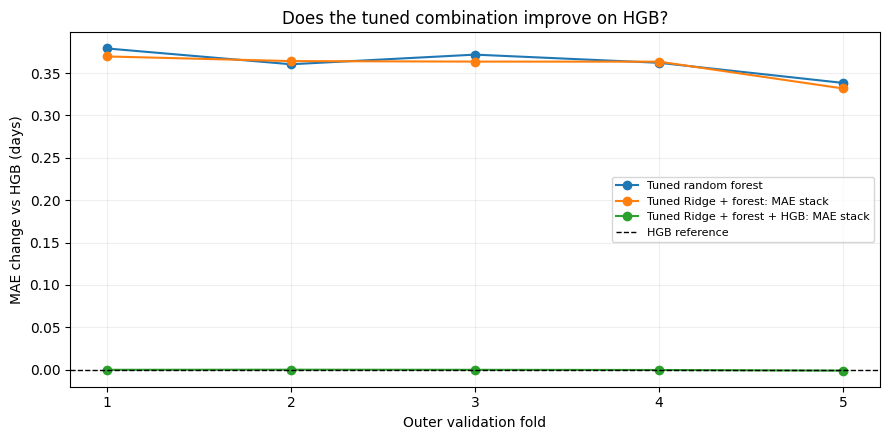

In [5]:
focus = ["forest_tuned", "stack_two_tuned", "stack_three_tuned"]
hgb = folds.loc[folds.model.eq("hgb")].set_index("outer_fold").MAE_days
fig, ax = plt.subplots(figsize=(9, 4.5))
for name in focus:
    value = folds.loc[folds.model.eq(name)].set_index("outer_fold").MAE_days - hgb
    ax.plot(value.index, value, marker="o", label=labels[name])
ax.axhline(0, color="black", linewidth=1, linestyle="--", label="HGB reference")
ax.set(xlabel="Outer validation fold", ylabel="MAE change vs HGB (days)",
       title="Does the tuned combination improve on HGB?")
ax.set_xticks(range(1, 6))
ax.grid(alpha=.2)
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## Reproduction and Scope

The [reproduction guide](../../random_stacking/nested_tuning/README.md) documents the three training/combination runners and independent verifier. Original notebooks, prior results, and published model code remain unchanged. Order-level predictions and fitted models are local files under the ignored `random_stacking/runs/nested_tuning_v1/` directory; only aggregate tables belong in the report.

This experiment evaluates a bounded tuning procedure. It does not perform a final full-training deployment refit or a new holdout evaluation. The existing holdout has already informed earlier work. A new claim about future orders would require a later evaluation cohort and features available at prediction time.


In [6]:
print("Saved verification checks:")
for name, value in validation.get("checks", {}).items():
    print(f"- {name}: {value}")
print("Full verification requires the local training artifacts; notebook execution checks saved aggregate hashes.")


Saved verification checks:
- Exact published training IDs and outer fold assignments: True
- Every candidate selected by mean inner-fold MAE with predefined tie order: True
- All classic inner and outer prediction models replayed: True
- Optional parity against previous fixed-trial OOF: checked
- Fold-fitted classic imputation and time encodings: True
- All 15 HGB regressors and all 60 deeper risk models replayed: True
- HGB risk feature fitting excludes its prediction rows and outer validation: True
- HGB outer predictions used only as corresponding outer scores: True
- Meta matrices use only inner OOF within each outer training partition: True
- Every learned simplex objective checked against an independent optimum: True
- Every outer score and public comparison recomputed: True
- Source review confirms no old holdout load, prediction or scoring route: True
Full verification requires the local training artifacts; notebook execution checks saved aggregate hashes.
